# SCC on Cell Lines Data
To assess if the higher density of the cell line data affects the ability of clustering using other metric than UOT, we'll calculate pairwise SCC scores on chr1 of this data.

## Imports 

In [1]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [10]:
### Directories and Files ###
root = '../../../'
metadata_dir = root+'Generated Data/Single-to-single/sc_uot_ramani/Metadata/maxnorm_total_mass.csv'
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = root+'Generated Data/Single-to-single/sc_scc_ramani'

In [ ]:
### Imports ###
import sys
import pandas as pd
import cooler
import matplotlib.pyplot as plt
import seaborn as sns
from time import perf_counter
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, scc_bulk

In [16]:
### Pre-importing metadata ###
metadata_df = pd.read_csv(metadata_dir, index_col=0)
metadata_df

,cell_name,total_mass_1mb_87,total_mass_1mb_95,total_mass_1mb_98,total_mass_2mb_85,total_mass_4mb_85,cell_line
0,cell231_HAP1_,1941.566416,938.503117,360.011112,516.899966,120.767018,HAP1
1,cell447_HAP1_,571.521891,495.144885,289.556840,136.625814,34.354590,HAP1
2,cell470_HAP1_,586.339846,490.376493,275.947577,138.433529,45.520736,HAP1
3,cell312_HAP1_,1108.256462,741.299690,328.747511,265.206067,69.050665,HAP1
4,cell29_HAP1_,1675.821060,883.559129,355.572255,435.640040,113.949017,HAP1
...,...,...,...,...,...,...,...
615,cell63_HeLa_,1577.132727,831.020976,352.527350,403.021046,110.950627,HeLa
616,cell54_HeLa_,1417.336487,833.285618,352.084282,354.485148,86.897894,HeLa
617,cell549_K562_,1388.605358,838.461384,350.797609,338.676013,90.951444,K562
618,cell219_HeLa_,1573.195954,869.111472,362.481811,391.248261,97.703535,HeLa


## Helper Functions

### Data Handling

In [ ]:
def subset_clr_data(data_dir: str, metadata: pd.DataFrame, count: int=20, seed: int=42) -> list[cooler.Cooler]:
    '''
        Takes a directory of cooler files, selects the number of cells specified
        by count per cell line given in metadata.

        Function is specific to formatting in this notebook.

        Parameters
        ----------
        data_dir : str
            The path to the folder containing the data.
        metadata : pd.DataFrame
            Metadata dataframe providing a mapping for file to cell
            line.
        count : int
            Number of cells to import per cell line.
            Default = 20.
        seed : int
            Seed used for randomization
            Default = 42.

        Returns
        -------
        clrs_subset : list(cooler.Cooler)
            List of coolers from specified subset.
    '''
    # Selecting files
    sampled_files = (
        metadata.groupby('cell_line')
                .apply(lambda x: x.sample(
                    n=min(len(x), count),
                    replace=False,
                    random_state=seed
                ))
                .reset_index(drop=True)
    )
    samples = list(sampled_files["cell_name"])

    # Importing coolers
    clrs_subset = import_cool_dir(data_dir, include=samples)
    return clrs_subset

def long_transform(ot_data: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    '''
        Takes a file-to-file comparisons matrix with scc results and
        transforms these results into a long format, also providing
        row and column cell lines.

        Parameters
        ----------
        ot_data : pd.DataFrame
            File-to-file format OT results.
        metadata : pd.DataFrame
            Metadata providing the cell line per file name.
        
        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format dataframe additionally giving row and column
            cell lines.
    '''
    # Mapping file to type
    type_lookup = metadata.set_index("cell_name")["cell_line"]

    # Long format
    ot_results_long = ot_data.reset_index().rename(columns={"index": "row_file"})
    ot_results_long = ot_results_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    
    # Mapping celltypes
    ot_results_long["row_cell_line"] = ot_results_long["row_file"].map(type_lookup)
    ot_results_long["col_cell_line"] = ot_results_long["col_file"].map(type_lookup)

    # Inter and intra
    ot_results_long["relationship"] = (
        ot_results_long["row_cell_line"] == ot_results_long["col_cell_line"]
        ).map({True: "intra", False: "inter"})

    return ot_results_long

def generate_scc_data(
        count: int=20, 
        seed: int=42
        ) -> tuple[pd.DataFrame, float]:
    '''
        Generates pair-wise scc comparison data for the cell line data
        using the provided arguments. Additionally, keeps track of computation
        time.

        Function is specific to this notebook.

        Parameters
        ----------
        cell_count : int
            The top number of cells to be used.
            Default = 20.
        seed : int
            Seed for subsetting
            Default = 42.

        Returns
        -------
        scc_results_long : pd.DataFrame
            Long format pandas dataframe with the desired results.
        end_time : float
            Calculation time in seconds.
    '''
    # Subsetting
    clrs = subset_clr_data(data_dir, metadata_df, count, seed)
    
    # SCC
        # Starting timer
    start_time = perf_counter()

        # Calculations
    scc_results = scc_bulk(clrs, clrs, chr_names=["chr1"])
    
        # Stopping timer
    end_time = perf_counter() - start_time

        # Saving results
    scc_results.to_csv(f'{save_dir}/CELL_LINES_scc_{count}_seed={seed}.csv')

    # Transforming to long format
    scc_results_long = long_transform(scc_results, metadata_df)

    return scc_results_long, end_time

def load_scc_results_long(
        folder: str,
        metadata: pd.DataFrame, 
        count: int=20, 
        seed: int=42
        ) -> pd.DataFrame:
    '''
        Loads all csv files corresponding to scc results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        metadata : pd.Dataframe
            Metadata providing the cell line per file name.
        count : int
            Number of cells used for analysis.
            Default = 20.
        seed : int
            Seed used to select data.
            Default = 42.
        
        Returns
        -------
        scc_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            scc results.
    '''
    # File
    file = f"{folder}/CELL_LINES_scc_{count}_seed={seed}.csv"

    # Importing file
    scc_df = pd.read_csv(file, index_col=0)

    # Covert to long and concatenate
    scc_df_long = long_transform(scc_df, metadata)

    return scc_df_long

### Visualization

In [34]:
def distribution_plot(data: pd.DataFrame, ax, seed: int, count: int):
    '''
        Plots the distribution of the provided dataframe to
        the provided Axes object.

        Function is very specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Data to be plotted.
        ax
            Axes object to plot to.
        seed : int
            Used seed.
        count : int
            Number of cells per cell line used.
    '''
    # Setting order
    order = ["inter", "intra"]

    # Stripplot
    sns.stripplot(
    data=data,
    x="relationship",
    y="value",
    order=order,
    hue="relationship",
    dodge=False,
    jitter=True,
    alpha=0.05,
    palette={
        "inter": "#1f77b4",
        "intra": "#ff7f0e"
    },
    ax=ax
    )

    # Violin plot
    sns.violinplot(
        data=data,
        x="relationship",
        y="value",
        order=order,
        inner=None,
        color="lightgray",
        cut=0,
        ax=ax
    )

    ax.set_ylim(bottom=0)
    ax.set_ylabel("SCC Chr1")
    ax.set_title(f"SCC Cell Lines for seed={seed}, count={count}", fontweight="bold")
    return

def generate_clustermap(data: pd.DataFrame, seed: int, count: int):
    '''
        Generates a clustermap between cell types for the data generated
        in this notebook.

        Function is specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Long format dataframe with cell-to-cell comparisons.
        seed : int
            Used seed for data selection.
        count : int
            Number of cells per cell line used.
    '''
    # Calculating means per cell type
    mean_matrix = data.groupby(
        ['row_cell_line', 'col_cell_line']
    )["value"].mean()

    # Prepping for generating heatmap
    heatmap_data = mean_matrix.unstack()

    # Clustermap
    sns.clustermap(heatmap_data, annot=True, fmt='.3f', cmap='viridis')
    plt.suptitle(f"SCC Cell Lines (seed={seed}, count={count})", fontweight='bold')
    plt.tight_layout()

    return

## Ramani Data

### Generating Data
Here, we'll use count = 38 and seed = 42 to match the results in cell_lines_clustering.ipynb.

In [23]:
### Generating Data ###
generate_scc_data(38, 42)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_7678/1633547682.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integ

(               row_file       col_file     value row_cell_line col_cell_line  \
 0         cell547_K562_  cell547_K562_  1.000000          K562          K562   
 1         cell434_HeLa_  cell547_K562_  0.300049          HeLa          K562   
 2      cell583_GM12878_  cell547_K562_  0.186477       GM12878          K562   
 3           cell7_HeLa_  cell547_K562_  0.258427          HeLa          K562   
 4          cell35_HAP1_  cell547_K562_  0.256772          HAP1          K562   
 ...                 ...            ...       ...           ...           ...   
 21604     cell537_K562_  cell381_HAP1_  0.242630          K562          HAP1   
 21605     cell500_K562_  cell381_HAP1_  0.328149          K562          HAP1   
 21606     cell284_HeLa_  cell381_HAP1_  0.272122          HeLa          HAP1   
 21607     cell112_HeLa_  cell381_HAP1_  0.303003          HeLa          HAP1   
 21608     cell381_HAP1_  cell381_HAP1_  1.000000          HAP1          HAP1   
 
       relationship  
 0  

### Loading Data

In [24]:
scc_data_subset = load_scc_results_long(save_dir, metadata_df, 38, 42)
scc_data_subset

,row_file,col_file,value,row_cell_line,col_cell_line,relationship
0,cell547_K562_,cell547_K562_,1.000000,K562,K562,intra
1,cell434_HeLa_,cell547_K562_,0.300049,HeLa,K562,inter
2,cell583_GM12878_,cell547_K562_,0.186477,GM12878,K562,inter
3,cell7_HeLa_,cell547_K562_,0.258427,HeLa,K562,inter
4,cell35_HAP1_,cell547_K562_,0.256772,HAP1,K562,inter
...,...,...,...,...,...,...
21604,cell537_K562_,cell381_HAP1_,0.242630,K562,HAP1,inter
21605,cell500_K562_,cell381_HAP1_,0.328149,K562,HAP1,inter
21606,cell284_HeLa_,cell381_HAP1_,0.272122,HeLa,HAP1,inter
21607,cell112_HeLa_,cell381_HAP1_,0.303003,HeLa,HAP1,inter


### Visualizing Data

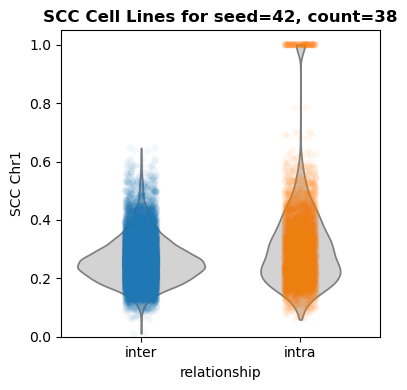

In [35]:
### Distribution Plot ###
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

distribution_plot(scc_data_subset, ax, 42, 38)

plt.tight_layout()

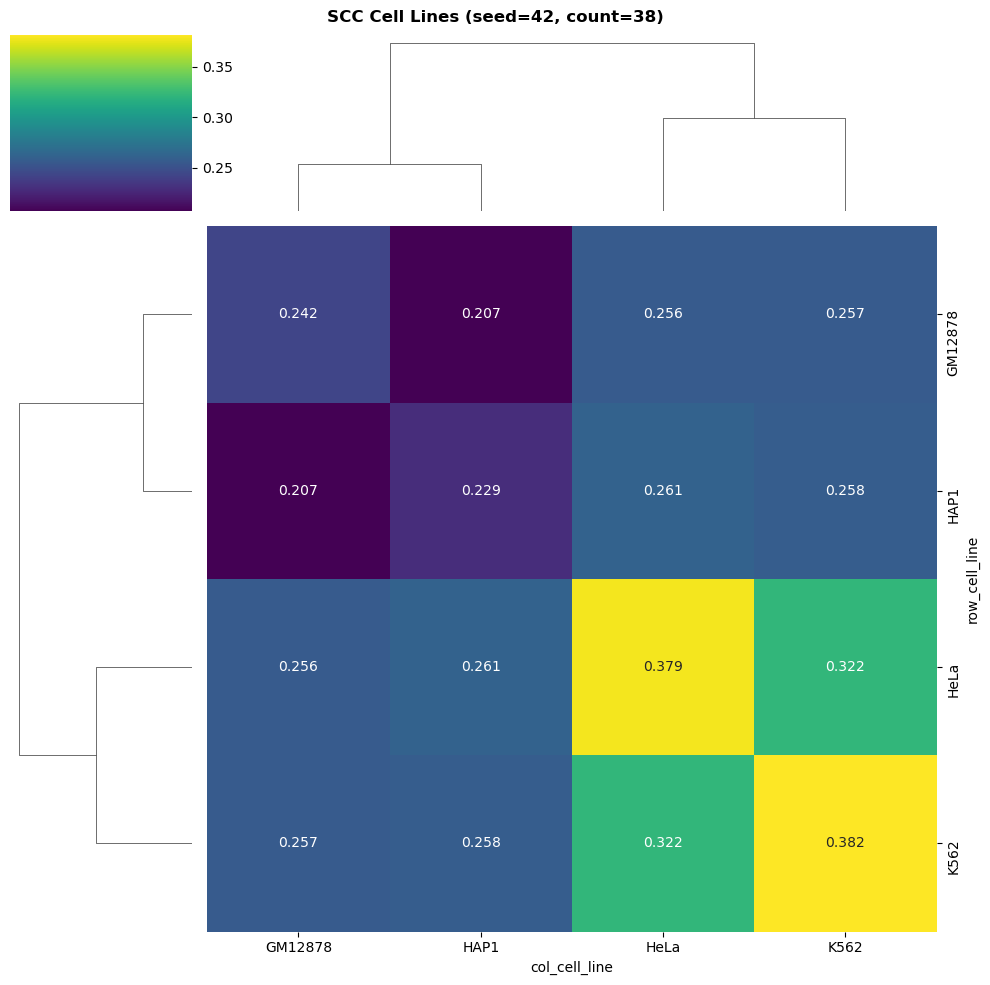

In [33]:
### Clustermap ###
generate_clustermap(scc_data_subset, 42, 38)

Clustering is similar to UOT, not matching Higashi results. To see if the increased computational cost of UOT is still worth it, we'll perform this analysis for the immune cell data as well.